# Plot scan

In [19]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../')
from auxPlots import interpolateData,getContours,saveContours
pd.option_context('display.max_columns', -1)

pd.options.mode.chained_assignment = None #Disable copy warnings
# plt.style.use('fivethirtyeight') #Set style
# mpl.rcParams.update({'figure.figsize' : (15,10)})  #Set general plotting options
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']

#### Create txname/process translator

In [25]:
processDict = {'T2tt' : r'$\tilde{t} \, \tilde{t}, \tilde{t} \to t \chi$',
              'T2bbffff' : r'$\tilde{t} \, \tilde{t}, \tilde{t} \to b W^* \chi$',
              'T2bbWW' : r'$\tilde{t} \, \tilde{t}, \tilde{t} \to b W \chi$'}
def convertLabel(label):
    newlabel = label[:]
    #Replace txnames by process
    for txlabel,proc in processDict.items():
        newlabel = newlabel.replace(txlabel,proc) 
    #Remove off-shell Ws and Zs from ATLAS analyses (since they only appear in on-shell cases)
    if 'ATLAS' in newlabel:
        newlabel = newlabel.replace('W^{(*)} Z^{(*)}', 'W Z')
    return newlabel


In [26]:
#Merge with SModelS DataFrame
#dataDF = pd.read_pickle('sms_smodels_new.pcl')
#dataDF = pd.read_pickle('VLF_smodels.pcl')
dataDF = pd.read_pickle('Zp_ttbar_smodels.pcl')
#print(dataDF)
print(dataDF.columns.values.tolist()) #Print all columns names

['filename', 'mass.5000001', 'mass.5000511', 'mass.5000512', 'mass.5000521', 'mass.9000002', 'mass.9000003', 'mass.9000004', 'width.5000001', 'width.5000511', 'width.5000512', 'width.5000521', 'width.9000002', 'width.9000003', 'width.9000004', 'xsec13TeV(fb).5000001', 'BRs.5000001.-6,6', 'pars.1', 'pars.2', 'pars.3', 'pars.4', 'pars.5', 'pars.6', 'pars.7', 'pars.8', 'pars.9', 'pars.10', 'pars.11', 'pars.12', 'pars.13', 'pars.14', 'pars.15', 'pars.16', 'pars.17', 'pars.18', 'pars.19', 'pars.20', 'pars.21', 'pars.22', 'pars.23', 'pars.24', 'pars.25', 'pars.26', 'pars.27', 'pars.28', 'pars.29', 'totalxsec13TeV(fb)', 'totalxsec8TeV(fb)', 'Total xsec for missing topologies (fb)', 'Total xsec for missing topologies with displaced decays (fb)', 'Total xsec for missing topologies with prompt decays (fb)', 'Total xsec for topologies outside the grid (fb)', 'OutputStatus.sigmacut', 'OutputStatus.minmassgap', 'OutputStatus.maxcond', 'OutputStatus.ncpus', 'OutputStatus.model', 'OutputStatus.prompt

#### Set r = 0 for points with no results 

In [27]:
#Set points without results with r == 0
dataDF.fillna(value={'ExptRes.result0.r' : 0.0},inplace=True)
#Sort points according to r value:
dataDF = dataDF.sort_values(by=['ExptRes.result0.r'],ascending=False)

#### Define exclusions

In [28]:
#Add simple flag for excluded points:
newDF = dataDF.copy()
newDF['excludedLHC'] = dataDF['ExptRes.result0.r'] > 1.0/1.6

#### Add c*tau and deltaM columns

In [29]:
#newDF['ctau.5000006'] = 1.967e-16/dataDF['width.5000006']
newDF['xsecXBR'] = dataDF['xsec13TeV(fb).5000001']*dataDF['BRs.5000001.-6,6']

### Get points excluded:

In [60]:
dataDF = newDF
excluded = dataDF[dataDF['excludedLHC'] == True]
allowed = dataDF[(dataDF['excludedLHC'] == False)]

print('Total number of points = %i' %len(dataDF))
print('Total excluded (LHC) = %i'%(len(excluded)))
print('Total allowed = %i\n'%(len(allowed)))

# print('Total excluded (r > %1.2f) = %i'%(rscale,len(excludedSC)))
# print('Total allowed (r > %1.2f) = %i'%(rscale,len(allowedSC)))


Total number of points = 1879
Total excluded (LHC) = 150
Total allowed = 1729



### Split data frame by analyis/txname

In [61]:
allAnas = []
allTx = []
useDF = dataDF
anaIDcols = [c for c in useDF.columns if '.AnalysisID' in c]
txIDcols = [c for c in useDF.columns if '.TxNames' in c]
for c in anaIDcols:
    allAnas += useDF[c].values.tolist()
for c in txIDcols:
    allTx += useDF[c].values.tolist()

allAnas = [a for a in allAnas if isinstance(a,str)]
allAnas = sorted(list(set(allAnas)))
allTx = [tuple(a) for a in allTx if isinstance(a,list)]
allTx = sorted(list(set(allTx)))
anaDFs = {}
for a in allAnas:
    anaDFs[a] = {}
    newrowList = []
    for irow,row in useDF.iterrows():
        ires = [col for col in anaIDcols if (row[col] == a)]
        if not ires:
            continue
        ires = ires[0]
        ires = ires.rsplit('.',1)[0]
        newrow = { }
        for c in dataDF.columns:
            if not 'ExptRes.result' in c:
                newrow[c] = row[c]
            elif c.rsplit('.',1)[0] == ires:
                newrow[c.replace(ires,'ExptRes.result')] = row[c]
        newrowList.append(newrow)
    if len(newrowList) != 0:
        anaDFs[a] = pd.DataFrame.from_dict(newrowList)
    # for tx in allTx:
    #     newrowList = []
    #     for irow,row in useDF.iterrows():
    #         ires = [col for col in anaIDcols if ((row[col] == a)  and row[col.replace('AnalysisID','TxNames')] == list(tx))]
    #         if not ires:
    #             continue
    #         ires = min(ires).rsplit('.',1)[0]
    #         newrow = { }
    #         for c in dataDF.columns:
    #             if not 'ExptRes.result' in c:
    #                 newrow[c] = row[c]
    #             elif c.rsplit('.',1)[0] == ires:
    #                 newrow[c.replace(ires,'ExptRes.result')] = row[c]
    #         newrowList.append(newrow)
    #     if len(newrowList) != 0:
    #         anaDFs[a][tx] = pd.DataFrame.from_dict(newrowList)

### Create analysis label for excluded points

In [62]:
anas = excluded['ExptRes.result0.AnalysisID'].value_counts()
anas.sort_values(inplace=True,ascending=False)

    
labels = []
for index, row in excluded.iterrows():
    ana = row['ExptRes.result0.AnalysisID']
    txList = sorted(row['ExptRes.result0.TxNames'])
    label = ana + ' (' + ','.join(txList) + ')'
    label = label.replace('off','') #Group together on and off-shell topologies
    labels.append(label)
excluded['label'] = labels
#print(excluded['label'])


In [63]:
nexcluded = [[len(excluded[excluded['label'] == label]),label] for label in excluded['label'].unique()]
nexcluded = sorted(nexcluded,reverse=True)
nexcluded = np.array(nexcluded)
for label in nexcluded[:,1]:
    print(label+': %i'%len(excluded[excluded['label'] == label]))

ATLAS-EXOT-2018-48 (TRV1tt): 150


### Define colors and plotting order

In [64]:
colors = sns.color_palette("Paired",len(excluded['label'].unique()))
colorsPink = sns.color_palette("colorblind",8)
colorDict = {'ATLAS-EXOT-2018-48 (TRV1tt)' : colorsPink[4], #light pink
             'ATLAS-EXOT-2019-03 (TRV1jj)' : 'red', #red
             'CMS-EXO-19-012 (TRV1jj)' : 'darkblue', #dark blue
             'ATLAS-SUSY-2018-12 (T2bbffff)' : 'darkgreen', #dark green
             'CMS-PAS-SUS-16-052 (T2bbWW)' : 'lightblue', #light blue
             'Other' : 'darkpurple' #dark purple
             }
#Define plotting order:
plottingOrder = nexcluded[:,1]
#Add other analyses
for ana in excluded['label'].unique():
    if not ana in plottingOrder:
        plottingOrder.append(ana)

### Plot excluded points grouped by most excluding analysis

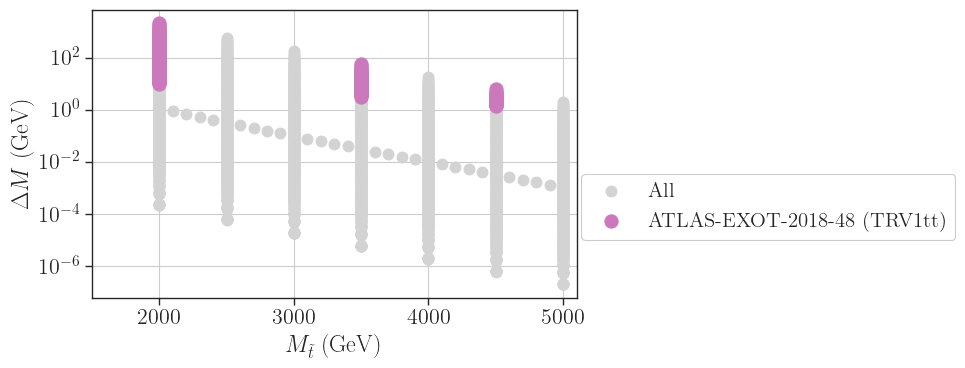

In [65]:
anas = excluded['label'].value_counts()
anas.sort_values(inplace=True,ascending=False)

plt.figure(figsize=(10,4))

x = allowed['mass.5000001']
y = allowed['xsecXBR']
# y = allowed['mass.5000012']
c_other = 'lightgray'
plt.scatter(x,y,color=c_other,label='All',s=60)

otherLabel = 'Others'
for ana in plottingOrder:
    x = excluded[excluded['label'] == ana]['mass.5000001']
    y = excluded[excluded['label'] == ana]['xsecXBR']
    if not ana in colorDict:
        color = colorDict['Other']        
        plt.scatter(x,y,color=color,label=otherLabel,s=90)
        otherLabel = None #suppress repeated label
    else:
        color = colorDict[ana]
        label = convertLabel(ana)
        plt.scatter(x,y,color=color,label=label,s=90)


lgd = plt.legend(loc=(1.01,0.2), framealpha=1.,fontsize=15)
plt.yscale('log')
plt.xlabel(r'$M_{\tilde{t}}$ (GeV)')
plt.ylabel(r'$\Delta M$ (GeV)')
plt.tight_layout()
# plt.savefig('stop_exclusion_deltaM.png')
plt.xlim(1500,5100)
# plt.ylim(0,1000)
plt.grid()
plt.show()

In [66]:
contoursDictAna = {}
for ana in anaDFs:
    anaDF = anaDFs[ana]
    if len(anaDF[anaDF['ExptRes.result.r'] > 1.0]) == 0:
        continue
    x = anaDF['mass.5000001']
    dm = anaDF['xsecXBR']
    z = anaDF['ExptRes.result.r']
    xnew,ynew,znew = interpolateData(x,dm,z)
    if xnew is None:
        continue
    # Get contours
    cValues = sorted([1.,1./1.5])
    cList = getContours(xnew,ynew,znew,cValues)
    if len(cList) > 0:
        contoursDictAna[ana] = cList


In [92]:
#Define the conditions for the points to remove
#cond1 = (dataDF['mass.5000006'] <= 225) & (dataDF['deltaM'] <= 80)
#cond2 = (dataDF['mass.5000006'] >= 500) & (dataDF['mass.5000006'] <= 1000) & (dataDF['deltaM'] == 80)
#cond3 = (dataDF['deltaM'] <= 7) 

#Filter the DataFrame to keep points that dont (~) match the conditions
#filteredDF = dataDF[~cond1 & ~cond2 & ~cond3]
#filteredDF = dataDF[~cond2 & ~cond3]
filteredDF = dataDF


x = filteredDF['mass.5000001']
dm = filteredDF['xsecXBR']
z = filteredDF['ExptRes.result0.r']

# Interpolate to create more points using the clean data
xnew, ynew, znew = interpolateData(x, dm, z)

# Get contours
cValues = sorted([1., 1./1.5])
contoursDict = getContours(xnew, ynew, znew, cValues)


target_val = 1./1.5
closest_key = min(contoursDict.keys(), key=lambda k: abs(k - target_val))

cList = contoursDict[closest_key]

if len(cList) > 0:
    contoursDictAna[ana] = cList

1672    140.65030
1448    116.94650
852      99.97131
724      93.27523
1456     83.43342
          ...    
720       0.00000
279       0.00000
278       0.00000
1315      0.00000
1301      0.00000
Name: ExptRes.result0.r, Length: 1879, dtype: float64


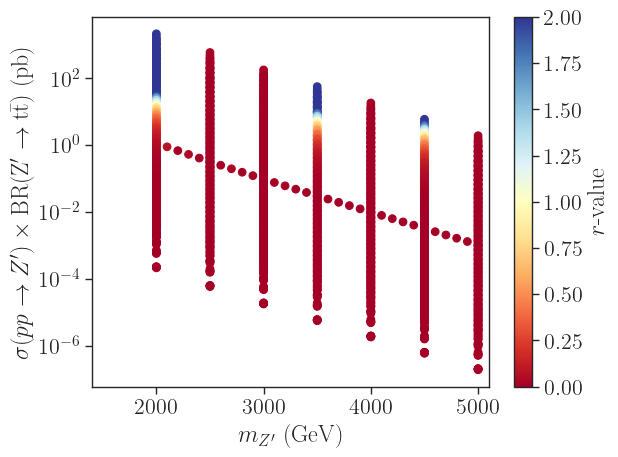

In [93]:
print(z)
plt.scatter(x,dm,c=z,cmap=cm,s=30,vmin=0.,vmax=2.)
plt.colorbar(label=r'$r$-value')
plt.xlabel(r'$m_{Z^\prime}$ (GeV)')
plt.ylabel(r'$\sigma(pp\to Z^\prime)\times\rm{BR}(Z^\prime \to t\bar{t})$ (pb)')
plt.xlim(1400.,5100.)
#plt.ylim(1e-5, 10.0)
plt.yscale('log')
#plt.scatter([225.0], [70.0])
plt.show()

In [99]:
import numpy as np

filteredDF = dataDF

x = filteredDF['mass.5000001']
# 1. Transform your cross-sections to Log Space before interpolating
dm_log = np.log10(filteredDF['xsecXBR']) 
z = filteredDF['ExptRes.result0.r']


# Interpolate to create more points
xnew, ynew_log, znew = interpolateData(x, dm_log, z)
ynew = 10**(ynew_log)

# 2. Feed the log-scaled y-values to the interpolator
xnew, ynew_log, znew = interpolateData(x, dm_log, z)

# 3. Transform the generated y-grid BACK to linear space for plotting and contours
ynew = 10**(ynew_log)

# Get contours (now using the properly unwrapped ynew)
cValues = sorted([1., 1./1.5])
contoursDict = getContours(xnew, ynew, znew, cValues)

target_val = 1./1.5
closest_key = min(contoursDict.keys(), key=lambda k: abs(k - target_val))

cList = contoursDict[closest_key]

if len(cList) > 0:
    contoursDictAna[ana] = cList

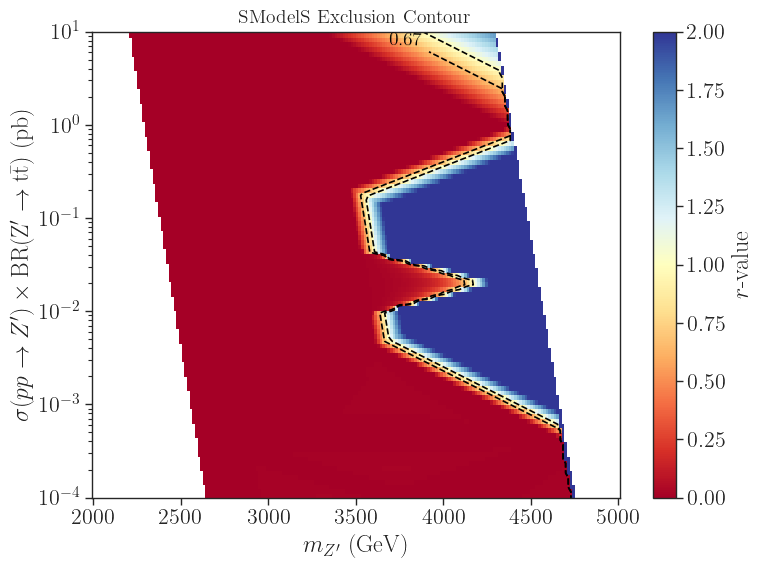

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# 1. Use pcolormesh instead of imshow for logarithmic compatibility
# It naturally maps the znew data to the xnew and ynew coordinates
color_map = plt.pcolormesh(xnew, ynew, znew.T, cmap=cm, vmin=0, vmax=2, shading='auto')

plt.colorbar(color_map, label=r'$r$-value')

# 2. Overlay the contours (ensure znew.T matches the orientation of pcolormesh)
contours = plt.contour(xnew, ynew, znew.T, cValues, colors='black', linestyles='dashed')
plt.clabel(contours, inline=True, fontsize=14, fmt='%1.2f')

# 3. Set the y-axis to logarithmic
plt.yscale('log')

# 4. Cleaned up labels for the Z' model
plt.xlabel(r'$m_{Z^\prime}$ (GeV)')
plt.ylabel(r'$\sigma(pp\to Z^\prime)\times\rm{BR}(Z^\prime \to t\bar{t})$ (pb)')

# Set the limits you requested to view the low cross-section floor
plt.ylim(1e-4, 10.0)
plt.title('SModelS Exclusion Contour', fontsize=14)

plt.tight_layout()
plt.show()

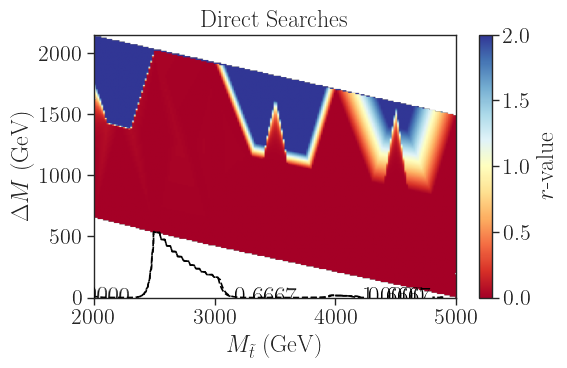

In [98]:
plt.figure(figsize=(6,4))
plt.imshow(znew.T, extent=[x.min(),x.max(), dm.min(), dm.max()], origin='lower',
                  cmap=cm,aspect='auto',vmin=0,vmax=2)
plt.colorbar(label=r'$r$-value')
plt.xlabel(r'$m_{T}$ (GeV)')
plt.ylabel(r'$\Delta M$ (GeV)')
contours = plt.contour(xnew, ynew, znew, cValues, colors='black',linestyles='dashed')
plt.clabel(contours, inline=True, fontsize=18)
# plt.yscale('log')
plt.title('Direct Searches')
#plt.yscale('log')
plt.xlabel(r'$M_{\tilde{t}}$ (GeV)')
plt.ylabel(r'$\Delta M$ (GeV)')
#plt.ylim(0.,10.)
plt.tight_layout()
plt.show()

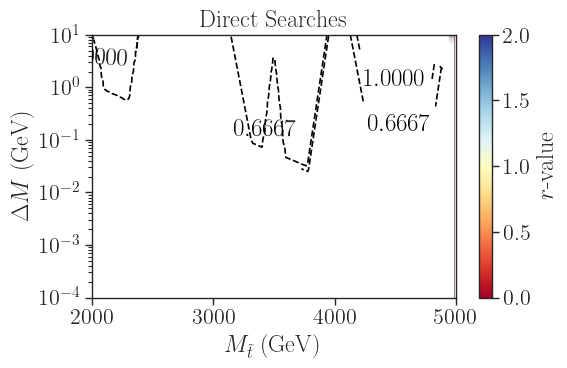

In [89]:
plt.figure(figsize=(6,4))
plt.imshow(znew.T, extent=[x.min(),x.max(), dm.min(), dm.max()], origin='lower',
                  cmap=cm,aspect='auto',vmin=0,vmax=2)
plt.colorbar(label=r'$r$-value')
plt.xlabel(r'$m_{T}$ (GeV)')
plt.ylabel(r'$\Delta M$ (GeV)')
contours = plt.contour(xnew, ynew, znew, cValues, colors='black',linestyles='dashed')
plt.clabel(contours, inline=True, fontsize=18)
#plt.yscale('log')
plt.title('Direct Searches')
plt.yscale('log')
plt.xlabel(r'$M_{\tilde{t}}$ (GeV)')
plt.ylabel(r'$\Delta M$ (GeV)')
plt.ylim(1e-4,10.)
plt.tight_layout()
plt.show()

### Save contour curves to text files

In [45]:
fname = 'SModelS_contours_Zp_ttbar.csv'
#saveContours(contoursDict,fname,header='mPsiT_GeV,deltaM_GeV')
saveContours(contoursDict,fname,header='mZp_GeV,xsecXBR_pb')


Contours saved to SModelS_contours_Zp_ttbar.csv
